#**MSC DISSERTATION ON EVALUATING GAN TRAINING STABILITY ACROSS DATA SIZE AND DENSITY REGIMES: HOW LITTLE DATA IS TOO LITTLE?**

#NAME: OLUWAMUYIWA JAIYEOLA
#STUDENT ID: 202255635:

### **Experimental Matrix Used: 2 x 4 x 2**
### The experimental design of this project comprises two GAN architectures, evaluated across four data sublevels and two datasets representing sparse and dense data regimes.

###**IMPORTANT NOTE:** This notebook contains code for training DCGAN at 100% data capacity for the dense dataset. This model was trained at four different dataset sub-levels: 100%, 50%, 25%, and 10%, but only the code for the 100% capacity is provided due to the submission limit. The model runs on the same codebase for all other dataset sub-levels and can be provided on request.

## Import the necessary libraries for data processing, GAN model development, evaluation metrics, and visualisation

In [ ]:
import os
import gc
import glob
import pandas as pd
from pathlib import Path
import random

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.neighbors import NearestNeighbors

from google.colab import drive

## Mount Google Drive for access to the dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## Define global hyperparameters and configuration settings for data processing, model architecture, and WGAN-GP training

In [ ]:
# HYPERPARAMETERS AND MODEL CONFIGURATION

# Data Parameters
IMG_SIZE     = 128
PATCH_STRIDE = 128
BATCH_SIZE   = 64
CHANNELS     = 3
DATA_DIR     = "/content/drive/MyDrive/Dataset_v2/Processed_v2"
VAL_SPLIT    = 0.2        # 20% reserved for Validation Metrics (FID)

# Dataset Configuration
# We set this to 1.0 for 100% (Full Dataset), 0.5 for 50%, 0.25 for 25% and 0.1 for 10%
DATA_SUBSET  = 1.0

# Model Architecture
LATENT_DIM   = 128
BASE_FILTERS = 64         # We keep this at 64 for fair comparison with WGAN-GP

# Training Parameters
EPOCHS       = 100
LEARNING_RATE = 0.0002    # Standard DCGAN LR (Radford et al.)
BETA_1       = 0.5        # Standard DCGAN Momentum

# Paths
SAMPLE_SAVE_DIR = f"/content/drive/MyDrive/Dataset_v2/Final_Model/DCGAN_v2_subset_{DATA_SUBSET}"
MODEL_SAVE_DIR = f"/content/drive/MyDrive/Dataset_v2/Final_Model/DCGAN_v2_Model_subset_{DATA_SUBSET}"

os.makedirs(SAMPLE_SAVE_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

## Set random seeds to ensure reproducibility across all libraries

In [ ]:
# Reproducibility Setup
SEED = 42

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Random seed set to {seed} for reproducibility.")

set_seeds(SEED)

Random seed set to 42 for reproducibility.


## Data Preprocessing: Build the tf.data input pipeline, which includes patch extraction, normalisation, dataset subsetting, and a 80/20 train/validation split for metric evaluation.

In [ ]:
# Dataset Pipeline with Train/Val Split (This is kept the same to match WGAN-GP for fair comparison)

def load_image_color_tf(path):
    # Loads an image and converts it to [0,1] float32
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img

def image_to_patches(path):

    # Extracts patches from a single image to augment the dataset.
    img = load_image_color_tf(path)          # [H,W,3]
    img = tf.expand_dims(img, 0)            # [1,H,W,3]

    ksize   = [1, IMG_SIZE, IMG_SIZE, 1]
    strides = [1, PATCH_STRIDE, PATCH_STRIDE, 1]
    rates   = [1, 1, 1, 1]

    patches = tf.image.extract_patches(
        images=img,
        sizes=ksize,
        strides=strides,
        rates=rates,
        padding='VALID'
    )

    patches = tf.reshape(patches, [-1, IMG_SIZE, IMG_SIZE, 3])
    # Normalizes data to [-1, 1] to match the Generator's Tanh output.
    patches = patches * 2.0 - 1.0
    return tf.data.Dataset.from_tensor_slices(patches)

def create_dataset_from_paths(file_paths, is_training=True):
    """
    This will create a tf.data.Dataset from a list of file paths.

    Args:
        is_training (bool): If True, shuffles and repeats the dataset.
                            If False (Validation), processes linearly once.
    """
    file_ds = tf.data.Dataset.from_tensor_slices(file_paths)

    if is_training:
        file_ds = file_ds.shuffle(buffer_size=len(file_paths))

    patch_ds = file_ds.interleave(
        lambda p: image_to_patches(p),
        cycle_length=8,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if is_training:
        patch_ds = patch_ds.shuffle(16384).repeat()

    # Batch and Prefetch
    patch_ds = (
        patch_ds
        .batch(BATCH_SIZE, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )
    return patch_ds

def prepare_train_val_datasets(folder, split=0.2, subset_fraction=1.0):
    """
    Splits the file list into Training and Validation sets to prevent data leakage.
    Allows selecting a random subset of the total data first.
    """
    folder_path = Path(folder)
    pattern = str(folder_path / "*.png")
    all_files = glob.glob(pattern)

    if not all_files:
        raise ValueError(f"No PNG files found under {folder_path}")

    # This will shuffle all files randomly
    random.shuffle(all_files)

    total_available = len(all_files)

    # This will select the subset of the dataset
    if subset_fraction < 1.0:
        subset_count = int(total_available * subset_fraction)
        selected_files = all_files[:subset_count]
        print(f"DATASET SUBSETTING APPLIED")
        print(f"Total Available: {total_available}")
        print(f"Selected Subset: {subset_count} images ({subset_fraction*100}%)")
    else:
        selected_files = all_files
        print(f"Using Full Dataset: {total_available} images")

    # Now, we split the subset into Train/Val
    split_idx = int(len(selected_files) * (1 - split))

    train_files = selected_files[:split_idx]
    val_files = selected_files[split_idx:]

    print(f"THE FINAL SPLIT")
    print(f"Training Files: {len(train_files)} ({(1-split)*100}%)")
    print(f"Validation Files: {len(val_files)} ({split*100}%)")

    train_ds = create_dataset_from_paths(train_files, is_training=True)
    val_ds   = create_dataset_from_paths(val_files, is_training=False) # There's no repeat and training is set to FALSE as this will only be use for validation

    return train_ds, val_ds, len(val_files)

# Let's initialize the datasets
train_dataset, val_dataset, val_count = prepare_train_val_datasets(DATA_DIR, split=VAL_SPLIT, subset_fraction=DATA_SUBSET)

# Let's create a dynamic metric sizing
# If we have fewer validation images than 1024 (e.g., in a 10% dataset subset),
# we must cap the metric samples to avoid errors or statistical mismatch.
METRIC_SAMPLE_SIZE = min(1024, val_count)
print(f"Metrics (FID/P/R) will be calculated using {METRIC_SAMPLE_SIZE} samples.")

Using Full Dataset: 4925 images
THE FINAL SPLIT
Training Files: 3940 (80.0%)
Validation Files: 985 (20.0%)
Metrics (FID/P/R) will be calculated using 985 samples.


## Define the DCGAN Generator architecture by projecting latent vectors into low-resolution feature maps, we progressively upsample them using transposed convolutions, apply Batch Normalisation and ReLU activations, and use a Tanh activation to output images in the range [-1, 1].

In [ ]:
# Model Architecture (DCGAN) Definition

# Building the Generator

def build_generator(latent_dim=128):
    """
    Standard DCGAN Generator.
    Uses Transposed Convolutions + Batch Norm + ReLU.
    """
    model = keras.Sequential(name="Generator")

    model.add(layers.Input(shape=(latent_dim,)))

    # We start with a dense layer to reshape into feature maps
    # We want to start at 8x8 spatial resolution
    start_dim = IMG_SIZE // 16 # 128 / 16 = 8
    n_nodes = start_dim * start_dim * (BASE_FILTERS * 8)

    model.add(layers.Dense(n_nodes))
    model.add(layers.Reshape((start_dim, start_dim, BASE_FILTERS * 8)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # Upsample: 8x8 -> 16x16
    model.add(layers.Conv2DTranspose(BASE_FILTERS * 4, (4,4), strides=(2,2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # Upsample: 16x16 -> 32x32
    model.add(layers.Conv2DTranspose(BASE_FILTERS * 2, (4,4), strides=(2,2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # Upsample: 32x32 -> 64x64
    model.add(layers.Conv2DTranspose(BASE_FILTERS, (4,4), strides=(2,2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # Upsample: 64x64 -> 128x128
    model.add(layers.Conv2DTranspose(CHANNELS, (4,4), strides=(2,2), padding='same', activation='tanh'))

    return model

# Instantiate Models
generator = build_generator(LATENT_DIM)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32768)          │     4,227,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 256)    │     2,097,408 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 3)    │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,986,947 (26.65 MB)

 Trainable params: 6,985,027 (26.65 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Define the DCGAN Discriminator architecture using strided convolutions for progressive downsampling, LeakyReLU activations and Dropout for regularisation, Batch Normalisation in deeper layers to stabilise training, and a final sigmoid-activated output layer to perform real or fake classification.

In [ ]:
# Building the Discriminator

def build_discriminator():
    """
    Standard DCGAN Discriminator.
    Uses Strided Convolutions + LeakyReLU + Dropout.
    Outputs a Probability (Sigmoid).
    """
    model = keras.Sequential(name="Discriminator")
    input_shape = (IMG_SIZE, IMG_SIZE, CHANNELS)

    model.add(layers.Input(shape=input_shape))

    # Downsample: 128 -> 64
    model.add(layers.Conv2D(BASE_FILTERS, (4,4), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Downsample: 64 -> 32
    model.add(layers.Conv2D(BASE_FILTERS * 2, (4,4), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Downsample: 32 -> 16
    model.add(layers.Conv2D(BASE_FILTERS * 4, (4,4), strides=(2,2), padding='same'))
    model.add(layers.BatchNormalization()) # BN helps stabilize deeper DCGANs
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Downsample: 16 -> 8
    model.add(layers.Conv2D(BASE_FILTERS * 8, (4,4), strides=(2,2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Output Layer (Real/Fake Classification)
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,792,385 (10.65 MB)

 Trainable params: 2,790,849 (10.65 MB)

 Non-trainable params: 1,536 (6.00 KB)

# Implement the DCGAN training loop as a custom Keras model for baseline comparison with WGAN-GP

In [ ]:
# DCGAN Training Class

class DCGAN(keras.Model):
    """
    Standard DCGAN Implementation.
    This serves as the baseline comparison for the WGAN-GP model.
    """
    def __init__(self, generator, discriminator, latent_dim):
        super(DCGAN, self).__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim

        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.d_acc_tracker = keras.metrics.BinaryAccuracy(name="d_accuracy")

    @property
    def metrics(self):
        return [self.g_loss_tracker, self.d_loss_tracker, self.d_acc_tracker]

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super(DCGAN, self).compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    @tf.function
    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        # Training the Discriminator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        generated_images = self.generator(random_latent_vectors)

        # Concatenate Real and Fake for efficient batch processing
        combined_images = tf.concat([generated_images, real_images], axis=0)

        # Soft Labels for Stability:
        # Fake = 0.0, Real = 0.9 (instead of 1.0) to prevent overconfidence
        labels = tf.concat(
            [tf.zeros((batch_size, 1)), tf.ones((batch_size, 1)) * 0.9], axis=0
        )

        with tf.GradientTape() as tape:
            d_predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, d_predictions)

        d_grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # Training the Generator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        # Generator wants D to think these are Real (1.0)
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            g_predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, g_predictions)

        g_grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # Metrics
        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)

        # Use d_predictions (from D step) and labels (Combined Real/Fake) to track real accuracy
        self.d_acc_tracker.update_state(labels, d_predictions)

        return {
            "g_loss": self.g_loss_tracker.result(),
            "d_loss": self.d_loss_tracker.result(),
            "d_acc": self.d_acc_tracker.result()
        }

## The DCGAN training setup involves instantiating the model using the defined generator and discriminator, configuring Adam optimisers with the standard DCGAN setting of β₁ = 0.5, and compiling the model using binary cross-entropy loss.

In [ ]:
# Setup DCGAN
# We are using standard Adam beta_1=0.5 for DCGAN

dcgan = DCGAN(generator, discriminator, LATENT_DIM)
# Compile DCGAN
dcgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1),
    g_optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

## Implement evaluation pipeline: InceptionV3 feature extraction for FID, preprocessing to 299×299, image snapshot monitoring, and periodic validation-based FID, Precision, and Recall computation with best-model saving


In [ ]:
# Evaluation Metrics and Callbacks

def get_inception_feature_extractor():
    #Returns the InceptionV3 model for feature extraction (FID).
    inception = tf.keras.applications.InceptionV3(
        include_top=False, pooling="avg", input_shape=(299, 299, 3)
    )
    return keras.Model(inputs=inception.input, outputs=inception.output)

def preprocess_for_inception(images):
    """
    Prepares images for InceptionV3.
    Includes Bicubic resizing to minimize artifacts on 128x128 images.
    """
    images_resized = tf.image.resize(
        images, (299, 299), method=tf.image.ResizeMethod.BICUBIC, antialias=True
    )
    # Rescale [-1, 1] -> [0, 255] range logic implicitly handled by preprocess_input
    return tf.keras.applications.inception_v3.preprocess_input((images_resized + 1.0) * 127.5)

class ImageMonitor(keras.callbacks.Callback):
    """
    This will saves generated images to disk periodically.
    This uses a fixed latent seed to track the evolution of the same faces over time.
    """
    def __init__(self, save_dir, latent_dim, num_img=16, every=20):
        super().__init__()
        self.save_dir = save_dir
        self.latent_dim = latent_dim
        self.every = every
        os.makedirs(self.save_dir, exist_ok=True)
        # Constant noise seed
        self.seed_z = tf.random.normal([num_img, self.latent_dim])

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every != 0: return
        fake_images = self.model.generator(self.seed_z, training=False)
        fake_images = tf.clip_by_value((fake_images + 1.0) / 2.0, 0.0, 1.0)

        fig, axs = plt.subplots(4, 4, figsize=(6, 6))
        idx = 0
        for i in range(4):
            for j in range(4):
                axs[i, j].imshow(fake_images[idx].numpy())
                axs[i, j].axis('off')
                idx += 1
        plt.tight_layout()
        filename = f"epoch_{epoch+1:04d}.png"
        path = os.path.join(self.save_dir, filename)
        plt.savefig(path, dpi=150)
        plt.show()
        plt.close()
        print(f"\n[Snapshot] Saved to {filename}")

class GenerativeMetrics(keras.callbacks.Callback):
    """
    Calculates FID, Precision, and Recall on the VALIDATION set.
    We use garbage collection to explicitly manage memory to prevent Colab from crashing.
    We also use a logic to save the best model based on FID Score
    """
    def __init__(self, val_dataset, save_dir, latent_dim, batch_size, every=20, num_samples=1024):
        super().__init__()
        # IMPORTANT: We use the VALIDATION dataset for metrics
        self.val_dataset = val_dataset
        self.save_dir = save_dir
        self.latent_dim = latent_dim
        self.batch_size = batch_size
        self.every = every
        self.num_samples = num_samples
        self.history_records = []
        self.inception_model = None

        # This tracks the best FID seen so far
        self.best_fid = float('inf')

    def on_train_begin(self, logs=None):
        if self.inception_model is None:
            self.inception_model = get_inception_feature_extractor()

    def get_features(self, images):
        processed = preprocess_for_inception(images)
        return self.inception_model(processed, training=False).numpy()

    def sample_real_features(self):
        all_feats = []
        count = 0
        # Iterate over validation dataset
        for batch in self.val_dataset:
            feats = self.get_features(batch)
            all_feats.append(feats)
            count += feats.shape[0]
            if count >= self.num_samples:
                break
        return np.vstack(all_feats)[:self.num_samples]

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every != 0: return

        print(f"\n[Metrics] Computing FID/Precision/Recall on Validation Set...")
        real_feats = self.sample_real_features()

        z = tf.random.normal([self.num_samples, self.latent_dim])
        fake_feats_list = []
        # Chunk generation to avoid OOM
        for i in range(0, self.num_samples, self.batch_size):
            z_chunk = z[i : i + self.batch_size]
            fake_imgs = self.model.generator(z_chunk, training=False)
            fake_feats_list.append(self.get_features(fake_imgs))
        fake_feats = np.vstack(fake_feats_list)

        # FID Calculation
        mu1, sigma1 = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
        mu2, sigma2 = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)
        diff = mu1 - mu2
        covmean = linalg.sqrtm(sigma1.dot(sigma2))
        if np.iscomplexobj(covmean): covmean = covmean.real
        fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

        # Precision/Recall Calculation
        k = 3
        nn_real = NearestNeighbors(n_neighbors=k).fit(real_feats)
        nn_fake = NearestNeighbors(n_neighbors=k).fit(fake_feats)

        dists_fake_to_real, _ = nn_real.kneighbors(fake_feats)
        dists_real_to_real, _ = nn_real.kneighbors(real_feats)
        manifold_radii = dists_real_to_real[:, -1]
        precision = (dists_fake_to_real[:, 0] <= np.percentile(manifold_radii, 95)).mean()

        dists_real_to_fake, _ = nn_fake.kneighbors(real_feats)
        dists_fake_to_fake, _ = nn_fake.kneighbors(fake_feats)
        manifold_radii_fake = dists_fake_to_fake[:, -1]
        recall = (dists_real_to_fake[:, 0] <= np.percentile(manifold_radii_fake, 95)).mean()

        print(f" -> FID: {fid:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

        # This checks and saves the best Epoch based on FID
        if fid < self.best_fid:
            print(f"  NEW BEST FID! (Improved from {self.best_fid:.2f} to {fid:.2f})")
            print(f"  Saving 'generator_best.keras'...")
            self.best_fid = fid
            self.model.generator.save(os.path.join(self.save_dir, "generator_best.keras"))

        self.history_records.append({
            "epoch": epoch + 1, "fid": float(fid),
            "precision": float(precision), "recall": float(recall)
        })
        df = pd.DataFrame(self.history_records)
        df.to_csv(os.path.join(self.save_dir, "metrics.csv"), index=False)
        gc.collect()


## Training execution: Train the DCGAN model on the training split using a fixed number of steps per epoch, then instantiate callbacks for visual monitoring and quantitative evaluation, and periodically compute FID, Precision, and Recall on the validation set.


DCGAN Training in Progress...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 380s 184ms/step - d_acc: 0.4193 - d_loss: 0.5961 - g_loss: 1.2349
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 123ms/step - d_acc: 0.4729 - d_loss: 0.4744 - g_loss: 1.8752
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - d_acc: 0.4833 - d_loss: 0.5141 - g_loss: 1.7025
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - d_acc: 0.4926 - d_loss: 0.4892 - g_loss: 1.6540
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - d_acc: 0.4934 - d_loss: 0.5202 - g_loss: 1.4277
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - d_acc: 0.4441 - d_loss: 0.5881 - g_loss: 1.3635
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - d_acc: 0.4165 - d_loss: 0.6057 - g_loss: 1.3787
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - d_acc: 0.4144 - d_loss: 0.6221 - g_loss: 1.3080
Epoch 9/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - d_acc: 0.4223 - d_l

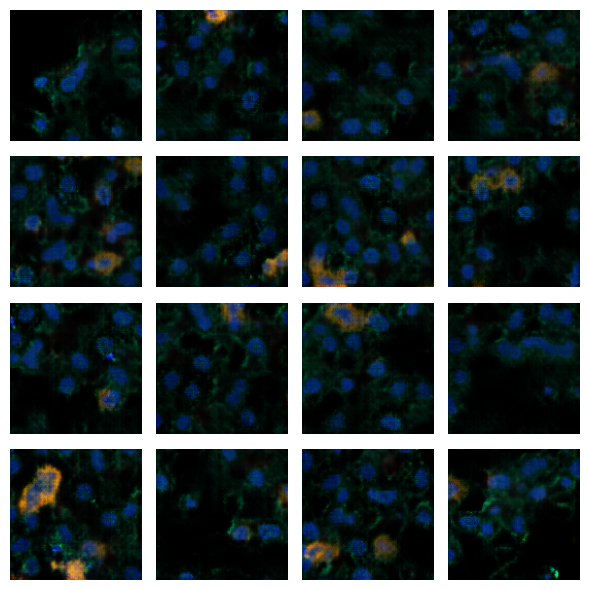


[Snapshot] Saved to epoch_0020.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 106.99 | Precision: 0.716 | Recall: 0.143
  NEW BEST FID! (Improved from inf to 106.99)
  Saving 'generator_best.keras'...
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 156ms/step - d_acc: 0.4093 - d_loss: 0.6214 - g_loss: 1.3035
Epoch 21/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - d_acc: 0.4123 - d_loss: 0.5978 - g_loss: 1.3314
Epoch 22/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4066 - d_loss: 0.6021 - g_loss: 1.3557
Epoch 23/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - d_acc: 0.4005 - d_loss: 0.9897 - g_loss: 1.8141
Epoch 24/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.3928 - d_loss: 0.6827 - g_loss: 0.9289
Epoch 25/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4143 - d_loss: 0.6249 - g_loss: 1.0617
Epoch 26/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - d_acc: 0.4065 - d_loss: 0.6167 - g_loss: 1.1928
Epoch 27/100
500/500 ━━━━━━━━━━━━━━━━━━

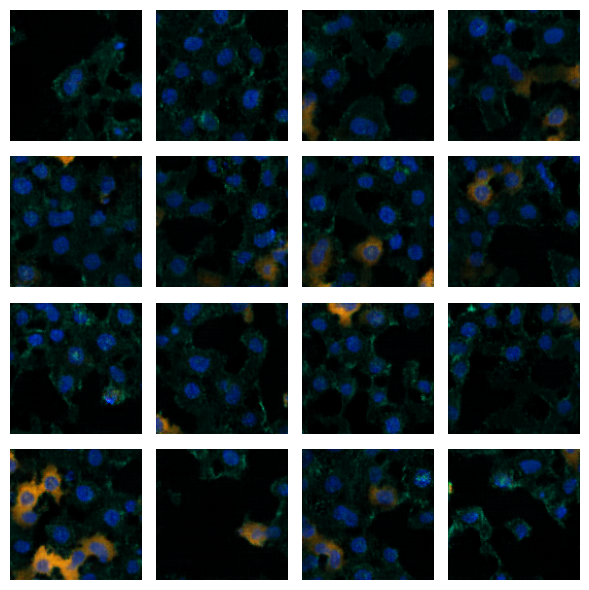


[Snapshot] Saved to epoch_0040.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 68.82 | Precision: 0.917 | Recall: 0.408
  NEW BEST FID! (Improved from 106.99 to 68.82)
  Saving 'generator_best.keras'...
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - d_acc: 0.4140 - d_loss: 0.5936 - g_loss: 1.4782
Epoch 41/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - d_acc: 0.4176 - d_loss: 0.5628 - g_loss: 1.4990
Epoch 42/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4249 - d_loss: 0.5456 - g_loss: 1.5109
Epoch 43/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4177 - d_loss: 0.5686 - g_loss: 1.4887
Epoch 44/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4251 - d_loss: 0.5487 - g_loss: 1.5153
Epoch 45/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4236 - d_loss: 0.5487 - g_loss: 1.5541
Epoch 46/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - d_acc: 0.4250 - d_loss: 0.5463 - g_loss: 1.5347
Epoch 47/100
500/500 ━━━━━━━━━━━━━━━━━

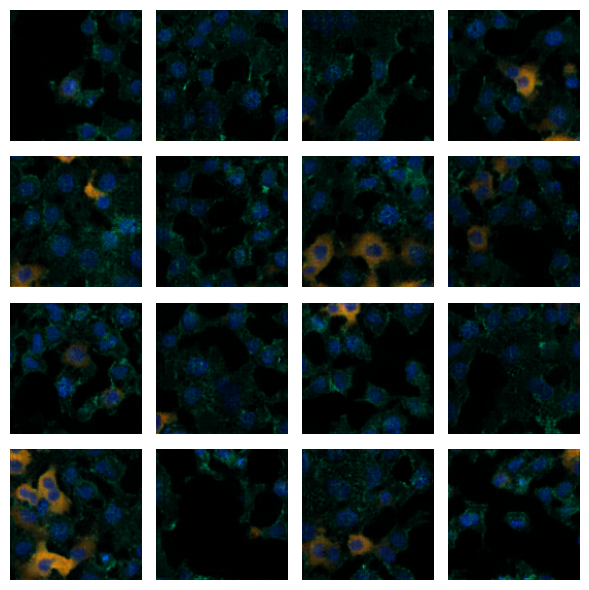


[Snapshot] Saved to epoch_0060.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 80.76 | Precision: 0.957 | Recall: 0.374
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 144ms/step - d_acc: 0.4298 - d_loss: 0.5668 - g_loss: 1.5693
Epoch 61/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - d_acc: 0.4183 - d_loss: 0.5719 - g_loss: 1.3016
Epoch 62/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - d_acc: 0.4312 - d_loss: 0.5330 - g_loss: 1.5116
Epoch 63/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4328 - d_loss: 0.5186 - g_loss: 1.5910
Epoch 64/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4294 - d_loss: 0.5519 - g_loss: 1.6001
Epoch 65/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4338 - d_loss: 0.5156 - g_loss: 1.6186
Epoch 66/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - d_acc: 0.4396 - d_loss: 0.4955 - g_loss: 1.7197
Epoch 67/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - d_acc: 0.4350 - d_loss: 0.5123 - g_loss: 1.6868
Epoch 68/100
50

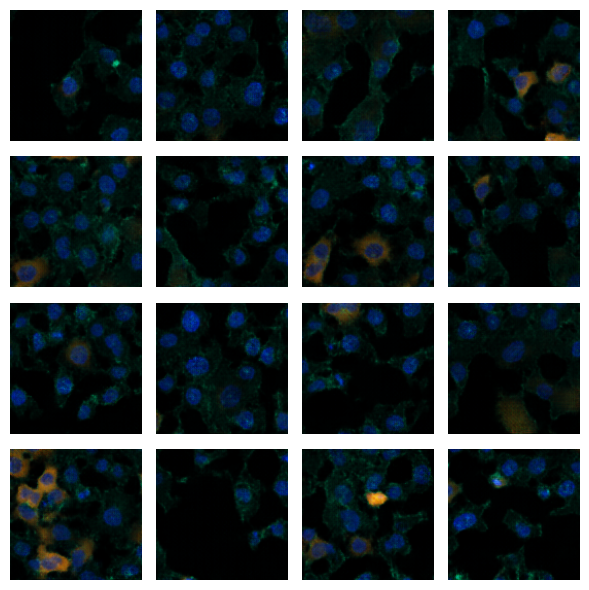


[Snapshot] Saved to epoch_0080.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 46.72 | Precision: 0.977 | Recall: 0.570
  NEW BEST FID! (Improved from 68.82 to 46.72)
  Saving 'generator_best.keras'...
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 141ms/step - d_acc: 0.4454 - d_loss: 0.4948 - g_loss: 1.4929
Epoch 81/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 77ms/step - d_acc: 0.4442 - d_loss: 0.4905 - g_loss: 1.5585
Epoch 82/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4497 - d_loss: 0.4697 - g_loss: 1.6826
Epoch 83/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - d_acc: 0.4452 - d_loss: 0.4814 - g_loss: 1.6940
Epoch 84/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - d_acc: 0.4447 - d_loss: 0.4713 - g_loss: 1.8059
Epoch 85/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - d_acc: 0.4421 - d_loss: 0.4907 - g_loss: 1.8407
Epoch 86/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - d_acc: 0.4436 - d_loss: 0.4720 - g_loss: 1.8499
Epoch 87/100
500/500 ━━━━━━━━━━━━━━━━━━

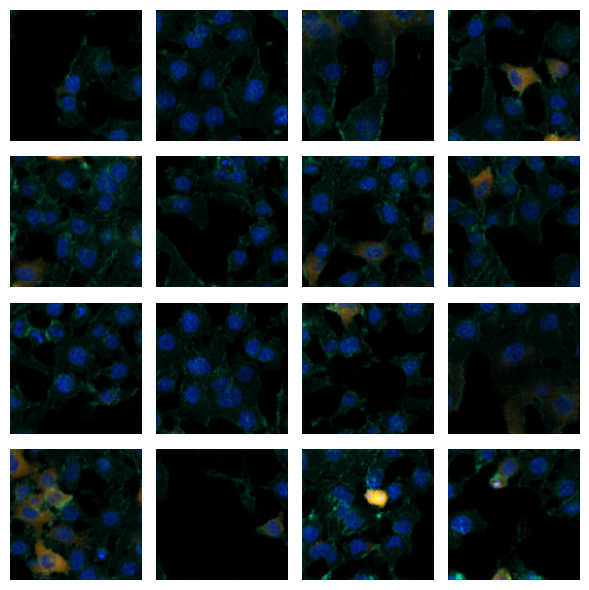


[Snapshot] Saved to epoch_0100.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 50.56 | Precision: 0.990 | Recall: 0.473
500/500 ━━━━━━━━━━━━━━━━━━━━ 75s 150ms/step - d_acc: 0.4556 - d_loss: 0.4400 - g_loss: 1.8660


In [ ]:
# Training Execution

# Instantiate the callbacks
img_monitor = ImageMonitor(SAMPLE_SAVE_DIR, LATENT_DIM, every=20)

metrics_monitor = GenerativeMetrics(
    val_dataset=val_dataset,            # This uses the validation set
    save_dir=MODEL_SAVE_DIR,
    latent_dim=LATENT_DIM,
    batch_size=BATCH_SIZE,
    every=20,                           # This will calculate metrics every 20 epochs
    num_samples=METRIC_SAMPLE_SIZE      # This is the number of images to be used for FID calculation, and this will be calculated using the dynamic sample size
)

print("DCGAN Training in Progress...")
history = dcgan.fit(
    train_dataset,                      # Training on the 80% split
    epochs=EPOCHS,
    steps_per_epoch=500,
    callbacks=[img_monitor, metrics_monitor]
)

## Save the final trained models, including the generator, critic, and DCGAN weights, to ensure reproducibility and support future inference.

In [ ]:
# Saving the trained Model & Final Evaluation

# Flag model as built for safe saving
dcgan.built = True
dcgan.generator.save(os.path.join(MODEL_SAVE_DIR, "generator_final.keras"))
dcgan.discriminator.save(os.path.join(MODEL_SAVE_DIR, "discriminator_final.keras"))
dcgan.save_weights(os.path.join(MODEL_SAVE_DIR, "dcgan_weights_final.weights.h5"))
print(f"Models saved to {MODEL_SAVE_DIR}")

Models saved to /content/drive/MyDrive/Dataset_v2/Final_Model/DCGAN_v2_Model_subset_1.0


## Perform final validation evaluation by reloading the trained generator and computing FID, Precision, and Recall using the same Inception-based feature pipeline


In [ ]:
# Final Evaluation on Validation Set
eval_gen = tf.keras.models.load_model(os.path.join(MODEL_SAVE_DIR, "generator_final.keras"), compile=False)

def calculate_metrics_standalone(generator, eval_dataset, latent_dim, num_samples=1024, batch_size=64):
    print(f"Starting final evaluation on {num_samples} images...")
    inception = get_inception_feature_extractor()

    def get_feats(images):
        return inception(preprocess_for_inception(images), training=False).numpy()

    real_feats_list = []
    count = 0
    for batch in eval_dataset:
        feats = get_feats(batch)
        real_feats_list.append(feats)
        count += feats.shape[0]
        if count >= num_samples: break
    real_feats = np.vstack(real_feats_list)[:num_samples]

    fake_feats_list = []
    for i in range(0, num_samples, batch_size):
        z = tf.random.normal([batch_size, latent_dim])
        fake_feats_list.append(get_feats(generator(z, training=False)))
    fake_feats = np.vstack(fake_feats_list)[:num_samples]

    # Metrics Calc
    mu1, sigma1 = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean = linalg.sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean): covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

    k = 3
    nn_real = NearestNeighbors(n_neighbors=k).fit(real_feats)
    nn_fake = NearestNeighbors(n_neighbors=k).fit(fake_feats)

    dists_fake_to_real, _ = nn_real.kneighbors(fake_feats)
    dists_real_to_real, _ = nn_real.kneighbors(real_feats)
    manifold_radii = dists_real_to_real[:, -1]
    precision = (dists_fake_to_real[:, 0] <= np.percentile(manifold_radii, 95)).mean()

    dists_real_to_fake, _ = nn_fake.kneighbors(real_feats)
    dists_fake_to_fake, _ = nn_fake.kneighbors(fake_feats)
    manifold_radii_fake = dists_fake_to_fake[:, -1]
    recall = (dists_real_to_fake[:, 0] <= np.percentile(manifold_radii_fake, 95)).mean()

    print(f"\n=== Final Report ===\nFID: {fid:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}")
    return fid, precision, recall

# Calculate metrics using the Validation Dataset
calculate_metrics_standalone(eval_gen, val_dataset, LATENT_DIM, num_samples=METRIC_SAMPLE_SIZE)

Starting final evaluation on 985 images...

=== Final Report ===
FID: 52.8506
Precision: 0.9848
Recall: 0.5046


(np.float64(52.85058137022645),
 np.float64(0.9847715736040609),
 np.float64(0.5045685279187817))

# VisualiZe DCGAN training dynamics by plotting generator and discriminator loss across epochs

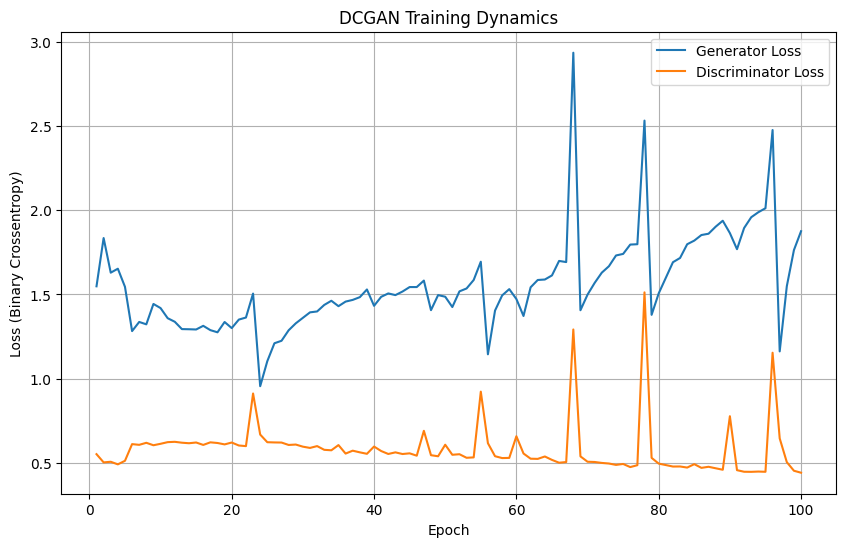

In [ ]:
# Plot Training Curves

plt.figure(figsize=(10, 6))
epochs = range(1, len(history.history["g_loss"]) + 1)
plt.plot(epochs, history.history["g_loss"], label="Generator Loss")
plt.plot(epochs, history.history["d_loss"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Crossentropy)")
plt.title("DCGAN Training Dynamics")
plt.legend()
plt.grid(True)
plt.show()

## Visualize generative performance by plotting FID alongside Precision and Recall over training epochs

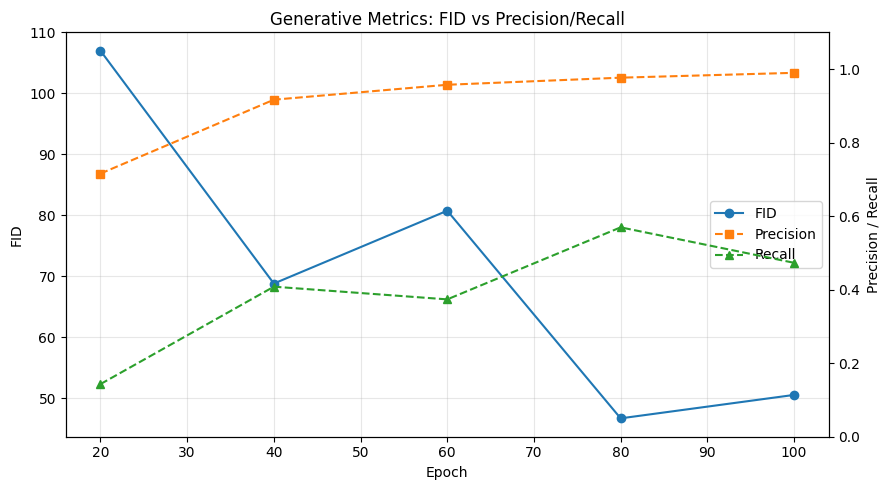

In [ ]:
# Plot FID/Precision/Recall
epochs_eval = [m["epoch"] for m in metrics_monitor.history_records]
fid_vals  = [m["fid"]   for m in metrics_monitor.history_records]
prec_vals = [m["precision"] for m in metrics_monitor.history_records]
rec_vals  = [m["recall"]    for m in metrics_monitor.history_records]

fig, ax1 = plt.subplots(figsize=(9, 5))

# FID (left axis)
ax1.plot(epochs_eval, fid_vals, 'o-', color="tab:blue", label="FID")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("FID")
ax1.grid(True, alpha=0.3)

# Precision/Recall (right axis)
ax2 = ax1.twinx()
ax2.plot(epochs_eval, prec_vals, 's--', color="tab:orange", label="Precision")
ax2.plot(epochs_eval, rec_vals, '^--', color="tab:green", label="Recall")
ax2.set_ylabel("Precision / Recall")
ax2.set_ylim(0, 1.1)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.title("Generative Metrics: FID vs Precision/Recall")
plt.tight_layout()
plt.show()

## Export recorded FID, Precision, and Recall values to a CSV file for reproducibility and post-training analysis

In [ ]:
# Save Metrics CSV

df_metrics = pd.DataFrame(metrics_monitor.history_records)
csv_path = os.path.join(MODEL_SAVE_DIR, "metrics_history.csv")
df_metrics.to_csv(csv_path, index=False)

print("Saved metrics history to:", csv_path)
print(df_metrics.head())

Saved metrics history to: /content/drive/MyDrive/Dataset_v2/Final_Model/DCGAN_v2_Model_subset_1.0/metrics_history.csv
   epoch         fid  precision    recall
0     20  106.989682   0.715736  0.143147
1     40   68.817429   0.916751  0.408122
2     60   80.758673   0.957360  0.373604
3     80   46.721966   0.976650  0.569543
4    100   50.561428   0.989848  0.473096
